# climagrid: interpretable, standards-based stress scores for grid assets

This notebook shows what climagrid does, end to end, on real public data:

1. **Accessibility** - a fleet of real substations to a stress table in one call, no API key.
2. **Interpretability** - every score traces to a named engineering standard and a specific weather input.
3. **Prioritization** - rank substations by the stress that matters, the "what do I inspect first" question.

**The assets are real.** They are eight real electric substations from OpenStreetMap (`power=substation`), with their real names, voltage levels, and coordinates, spanning very different U.S. climates. The weather pulled for them is real NASA POWER data for 2023, and the stress scores come from published IEEE and ASCE engineering standards.

**Scope, stated honestly:** climagrid quantifies the environmental *stress* on equipment. It does not predict which equipment will *fail*; turning these scores into failure predictions needs a utility's own failure records. See `docs/validation_notes.md`.

_Substation data (c) OpenStreetMap contributors, ODbL._

## Step 1: A fleet of real substations to a stress table in one call

Eight real electric substations (OpenStreetMap) across desert, Gulf, subtropical, mountain, Pacific Northwest, and northern-plains climates. climagrid fetches weather at each substation's own coordinates, so a geographically spread fleet works in a single call. No API key is needed for the NASA POWER source.

In [1]:
import tempfile
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd

import climagrid

# Real electric substations (OpenStreetMap, power=substation). Names, voltages,
# and coordinates are the OSM-recorded values. (c) OpenStreetMap contributors, ODbL.
fleet = pd.DataFrame([
    {"asset_id": "Kyrene",      "state": "AZ", "voltage_kv": 500, "lat": 33.3518, "lon": -111.9420},
    {"asset_id": "Addicks",     "state": "TX", "voltage_kv": 345, "lat": 29.8228, "lon": -95.5729},
    {"asset_id": "Flagami",     "state": "FL", "voltage_kv": 230, "lat": 25.7682, "lon": -80.3433},
    {"asset_id": "West Mesa",   "state": "NM", "voltage_kv": 345, "lat": 35.1140, "lon": -106.7236},
    {"asset_id": "Smoky Hill",  "state": "CO", "voltage_kv": 345, "lat": 39.6308, "lon": -104.7148},
    {"asset_id": "Maple Valley","state": "WA", "voltage_kv": 500, "lat": 47.4687, "lon": -122.1876},
    {"asset_id": "Terminal",    "state": "MN", "voltage_kv": 345, "lat": 44.9933, "lon": -93.2070},
    {"asset_id": "Bismarck",    "state": "ND", "voltage_kv": 230, "lat": 46.8136, "lon": -100.7290},
])

csv_path = Path(tempfile.mkdtemp()) / "fleet.csv"
fleet.to_csv(csv_path, index=False)

df = climagrid.run(
    str(csv_path),
    start_dt=datetime(2023, 1, 1, tzinfo=timezone.utc),
    end_dt=datetime(2024, 1, 1, tzinfo=timezone.utc),
    sources=["nasa_power"],  # no API key required
    features=["thermal", "conductor_sag", "ice_loading", "freeze_thaw", "soil"],
)
print(f"{df['asset_id'].nunique()} real substations, {len(df):,} substation-hours of 2023.")
print("columns:", [c for c in df.columns if c.startswith(("nasa_", "feat_"))])
df.head(3)

/home/devbot/.pyenv/versions/3.12.5/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


8 real substations, 70,272 substation-hours of 2023.
columns: ['nasa_temperature_2m', 'nasa_wind_speed_10m', 'nasa_solar_irradiance_ghi', 'nasa_relative_humidity_2m', 'nasa_precipitation', 'feat_thermal_aging_factor', 'feat_heat_hours_above_35c', 'feat_conductor_sag_index', 'feat_ice_loading_risk', 'feat_freeze_thaw_cycles', 'feat_soil_saturation_index']


,asset_id,timestamp,lat,lon,nasa_temperature_2m,nasa_wind_speed_10m,nasa_solar_irradiance_ghi,nasa_relative_humidity_2m,nasa_precipitation,feat_thermal_aging_factor,feat_heat_hours_above_35c,feat_conductor_sag_index,feat_ice_loading_risk,feat_freeze_thaw_cycles,feat_soil_saturation_index
0,Kyrene,2023-01-01 00:00:00+00:00,33.3518,-111.942,14.94,1.62,4.38,63.36,0.05,0.000157,0.0,0.0,0.0,0.0,0.0005
1,Kyrene,2023-01-01 01:00:00+00:00,33.3518,-111.942,13.93,2.05,0.00,65.25,0.05,0.000134,0.0,0.0,0.0,0.0,0.0010
2,Kyrene,2023-01-01 02:00:00+00:00,33.3518,-111.942,13.26,2.37,0.00,66.86,0.05,0.000121,0.0,0.0,0.0,0.0,0.0015


## Step 2: Every score is explainable

Take the most heat-stressed substation and show *why*: the weather it saw, the resulting stress value, and the engineering standard each value comes from. Nothing here is a black box.

In [2]:
STANDARD = {
    "feat_thermal_aging_factor": "IEEE C57.91 - transformer insulation aging (Arrhenius)",
    "feat_heat_hours_above_35c": "hours of heat exposure above 35 C",
    "feat_conductor_sag_index": "IEEE 738 (simplified) - conductor thermal sag",
    "feat_ice_loading_risk": "ASCE 7-22 (simplified) - ice accretion loading",
    "feat_freeze_thaw_cycles": "freeze-thaw cycle count (mechanical fatigue)",
    "feat_soil_saturation_index": "soil moisture accumulation",
}
feat_cols = [c for c in df.columns if c.startswith("feat_")]

peak = df.groupby("asset_id")["feat_thermal_aging_factor"].max()
top_id = peak.idxmax()
asset = df[df["asset_id"] == top_id]
worst_hour = asset.loc[asset["nasa_temperature_2m"].idxmax()]
kv = fleet.loc[fleet["asset_id"] == top_id, "voltage_kv"].iloc[0]

print(f"Most heat-stressed substation: {top_id} ({kv} kV)")
print(f"  Hottest hour in 2023: {worst_hour['nasa_temperature_2m']:.1f} C air temp, "
      f"{worst_hour['nasa_relative_humidity_2m']:.0f}% RH")
print("  Standards-based stress (peak over the year):")
for c in feat_cols:
    print(f"    {asset[c].max():8.3f}   {c:28s}  <- {STANDARD[c]}")

Most heat-stressed substation: Kyrene (500 kV)
  Hottest hour in 2023: 47.5 C air temp, 10% RH
  Standards-based stress (peak over the year):
       0.014   feat_thermal_aging_factor     <- IEEE C57.91 - transformer insulation aging (Arrhenius)
     105.000   feat_heat_hours_above_35c     <- hours of heat exposure above 35 C
       1.000   feat_conductor_sag_index      <- IEEE 738 (simplified) - conductor thermal sag
       0.422   feat_ice_loading_risk         <- ASCE 7-22 (simplified) - ice accretion loading
       6.000   feat_freeze_thaw_cycles       <- freeze-thaw cycle count (mechanical fatigue)
       1.000   feat_soil_saturation_index    <- soil moisture accumulation


## Step 2b: Verified against the IEEE C57.91 standard

Beyond being interpretable, the thermal aging factor is *correct*: it reproduces the published IEEE C57.91 aging-acceleration formula exactly. The check below re-implements that formula independently (constants hardcoded here, not imported from climagrid) and confirms climagrid's output matches at the recognizable reference points: an aging factor of 1.0 at the 110 C reference hotspot, and a value that roughly doubles for every ~8 C above it.

In [3]:
import numpy as np

from climagrid.features.thermal import ThermalStressIndex


# IEEE C57.91-2011, Sec 5.1 (thermally upgraded paper):
#   FAA = exp[ 15000/383.15 - 15000/(hotspot_C + 273.15) ], reference hotspot = 110 C.
# Constants are hardcoded here, NOT imported from climagrid, so this is an external check.
def ieee_c57_91_faa(hotspot_c):
    return np.exp(15000.0 / 383.15 - 15000.0 / (hotspot_c + 273.15))


hotspots = [80, 98, 110, 118, 120, 140]
# hotspot_rise=0 so the input temperature IS the hotspot temperature.
cg = (
    ThermalStressIndex(temp_col="hotspot_c", hotspot_rise=0.0)
    .compute(pd.DataFrame({"hotspot_c": hotspots, "asset_id": "ref"}))
    ["feat_thermal_aging_factor"].to_numpy()
)
reference = np.array([ieee_c57_91_faa(h) for h in hotspots])

print(f"{'hotspot C':>9}  {'climagrid':>10}  {'IEEE C57.91':>11}  match")
for h, c, r in zip(hotspots, cg, reference, strict=True):
    ok = 'OK' if abs(c - r) < 1e-9 else 'MISMATCH'
    print(f"{h:9d}  {c:10.4f}  {r:11.4f}  {ok}")

assert np.allclose(cg, reference, rtol=1e-9), "climagrid FAA does not match IEEE C57.91"
print("\nVerified: climagrid reproduces the IEEE C57.91 aging factor exactly.")
print(
    f"Anchors: 110 C -> {ieee_c57_91_faa(110):.3f} (reference = 1.0); "
    f"118 C -> {ieee_c57_91_faa(118):.2f} (roughly doubles every ~8 C)."
)

hotspot C   climagrid  IEEE C57.91  match
       80      0.0359       0.0359  OK
       98      0.2820       0.2820  OK
      110      1.0000       1.0000  OK
      118      2.2271       2.2271  OK
      120      2.7068       2.7068  OK
      140     17.1626      17.1626  OK

Verified: climagrid reproduces the IEEE C57.91 aging factor exactly.
Anchors: 110 C -> 1.000 (reference = 1.0); 118 C -> 2.23 (roughly doubles every ~8 C).


## Step 3: Which substations to look at first

Each climate stresses equipment differently. Ranking the fleet by each stress feature answers the operational question directly: for a given hazard, which substations carry the most exposure?

In [4]:
summary = df.groupby("asset_id")[feat_cols].max().round(3)
print("Peak stress per substation in 2023:\n")
print(summary.to_string())
print("\nWorst substation for each hazard:")
for c in feat_cols:
    print(f"  {c:28s} -> {summary[c].idxmax()}  ({summary[c].max():.3f})")

Peak stress per substation in 2023:

              feat_thermal_aging_factor  feat_heat_hours_above_35c  feat_conductor_sag_index  feat_ice_loading_risk  feat_freeze_thaw_cycles  feat_soil_saturation_index
asset_id                                                                                                                                                                
Addicks                           0.010                       72.0                       1.0                  0.578                      2.0                         1.0
Bismarck                          0.004                        5.0                       1.0                  0.871                     25.5                         1.0
Flagami                           0.002                        0.0                       1.0                  0.000                      0.0                         1.0
Kyrene                            0.014                      105.0                       1.0                  0.422   

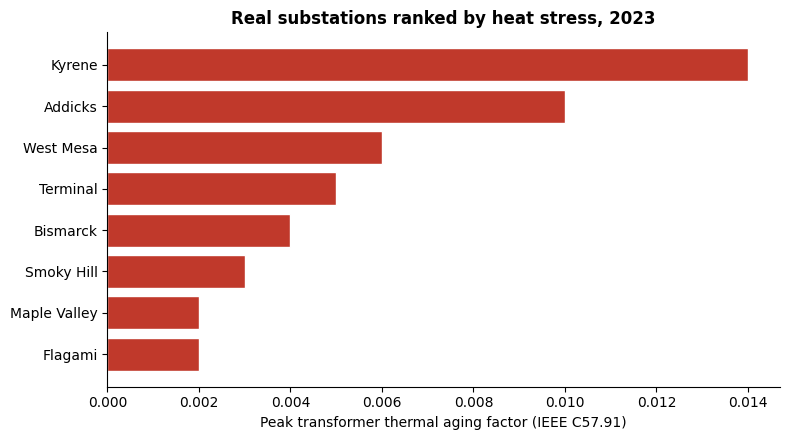

In [5]:
import matplotlib.pyplot as plt

ranked = summary["feat_thermal_aging_factor"].sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(ranked.index, ranked.values, color="#c0392b", edgecolor="white")
ax.set_xlabel("Peak transformer thermal aging factor (IEEE C57.91)")
ax.set_title("Real substations ranked by heat stress, 2023", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## What this shows, and what it does not

**Shows:** climagrid turns free public weather into interpretable, standards-based stress scores for real substations, anywhere in the U.S., in one call, and ranks them so an operator can see where the weather is hardest on its equipment. The desert and Gulf substations top heat stress; the northern ones top freeze-thaw and ice. The scores match physical reality and each one traces to a published standard.

**Does not show:** which equipment will fail. These are stress *inputs*, not failure predictions. To estimate failure risk, combine them with a substation's own maintenance and failure history and validate on that data. See `docs/validation_notes.md` for the honest boundary.

_Substation locations (c) OpenStreetMap contributors, ODbL. Coverage is community-contributed and most complete for transmission-level substations._